In [8]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. Load data (adjust path/name)
df = pd.read_csv("accepted_2007_to_2018Q4.csv.gz", low_memory=False)

# 2. Basic cleaning: keep completed loans only
completed_status = [
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
    "Does not meet the credit policy. Status:Fully Paid"
]
df = df[df["loan_status"].isin(completed_status)]

# 3. Create a default flag (1 = bad, 0 = good)
bad_status = ["Charged Off", "Default",
              "Does not meet the credit policy. Status:Charged Off"]
df["is_default"] = np.where(df["loan_status"].isin(bad_status), 1, 0)

# 4. Keep only Grade C and clean interest rate to numeric (%)
df_c = df[df["grade"] == "C"].copy()

# Handle int_rate - check if it's string or numeric
if df_c["int_rate"].dtype == 'object':
    # If string like "13.56%", remove % and convert
    df_c["int_rate_num"] = df_c["int_rate"].str.rstrip("%").astype(float)
else:
    # Already numeric
    df_c["int_rate_num"] = df_c["int_rate"]

# 5. Define A/B groups by median interest rate
median_rate = df_c["int_rate_num"].median()
df_c["group"] = np.where(df_c["int_rate_num"] <= median_rate, "A_low", "B_high")

# 6. Aggregate metrics by group
summary = (
    df_c
    .groupby("group")
    .agg(
        n_loans=("loan_amnt", "size"),
        mean_rate=("int_rate_num", "mean"),
        default_rate=("is_default", "mean")
    )
    .reset_index()
)

summary["margin"] = summary["mean_rate"]

print("Analysis complete!")
print(summary)

Analysis complete!
    group  n_loans  mean_rate  default_rate     margin
0   A_low   214154  13.125395      0.217726  13.125395
1  B_high   168169  15.157489      0.232968  15.157489


# A/B Test Results: Interest Rate Impact on Grade C Loans

## Test Setup
- **Control Group (A_low)**: Loans with interest rates ≤ median
- **Treatment Group (B_high)**: Loans with interest rates > median
- **Metric**: Default rate comparison

In [13]:
# 1. Summary Statistics Table
print("="*60)
print("A/B TEST SUMMARY - GRADE C LOANS")
print("="*60)
print(f"\nMedian Interest Rate Split: {median_rate:.2f}%\n")

summary_display = summary[['group', 'n_loans', 'mean_rate', 'default_rate']].copy()
summary_display['mean_rate'] = summary_display['mean_rate'].apply(lambda x: f"{x:.2f}%")
summary_display['default_rate'] = summary_display['default_rate'].apply(lambda x: f"{x:.2%}")
summary_display.columns = ['Group', 'Loan Count', 'Avg Interest Rate', 'Default Rate']

print(summary_display.to_string(index=False))
print("\n" + "="*60)

A/B TEST SUMMARY - GRADE C LOANS

Median Interest Rate Split: 13.99%

 Group  Loan Count Avg Interest Rate Default Rate
 A_low      214154            13.13%       21.77%
B_high      168169            15.16%       23.30%



In [10]:
# 2. Statistical Significance Test (Two-Proportion Z-Test)
group_a = df_c[df_c["group"] == "A_low"]
group_b = df_c[df_c["group"] == "B_high"]

# Count of defaults and total loans for each group
defaults = np.array([group_a["is_default"].sum(), group_b["is_default"].sum()])
totals = np.array([len(group_a), len(group_b)])

# Perform two-proportion z-test
z_stat, p_value = proportions_ztest(defaults, totals, alternative='two-sided')

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*60)
print(f"\nNull Hypothesis: Default rates are equal between groups")
print(f"Alternative Hypothesis: Default rates differ between groups")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} at α=0.05")
if p_value < 0.05:
    print(f"✓ The difference in default rates is statistically significant")
    diff = (group_b["is_default"].mean() - group_a["is_default"].mean()) * 100
    print(f"✓ Group B has {diff:.2f}% higher default rate")
print("="*60)


STATISTICAL SIGNIFICANCE TEST

Null Hypothesis: Default rates are equal between groups
Alternative Hypothesis: Default rates differ between groups

Z-statistic: -11.2124
P-value: 0.000000

Result: SIGNIFICANT at α=0.05
✓ The difference in default rates is statistically significant
✓ Group B has 1.52% higher default rate


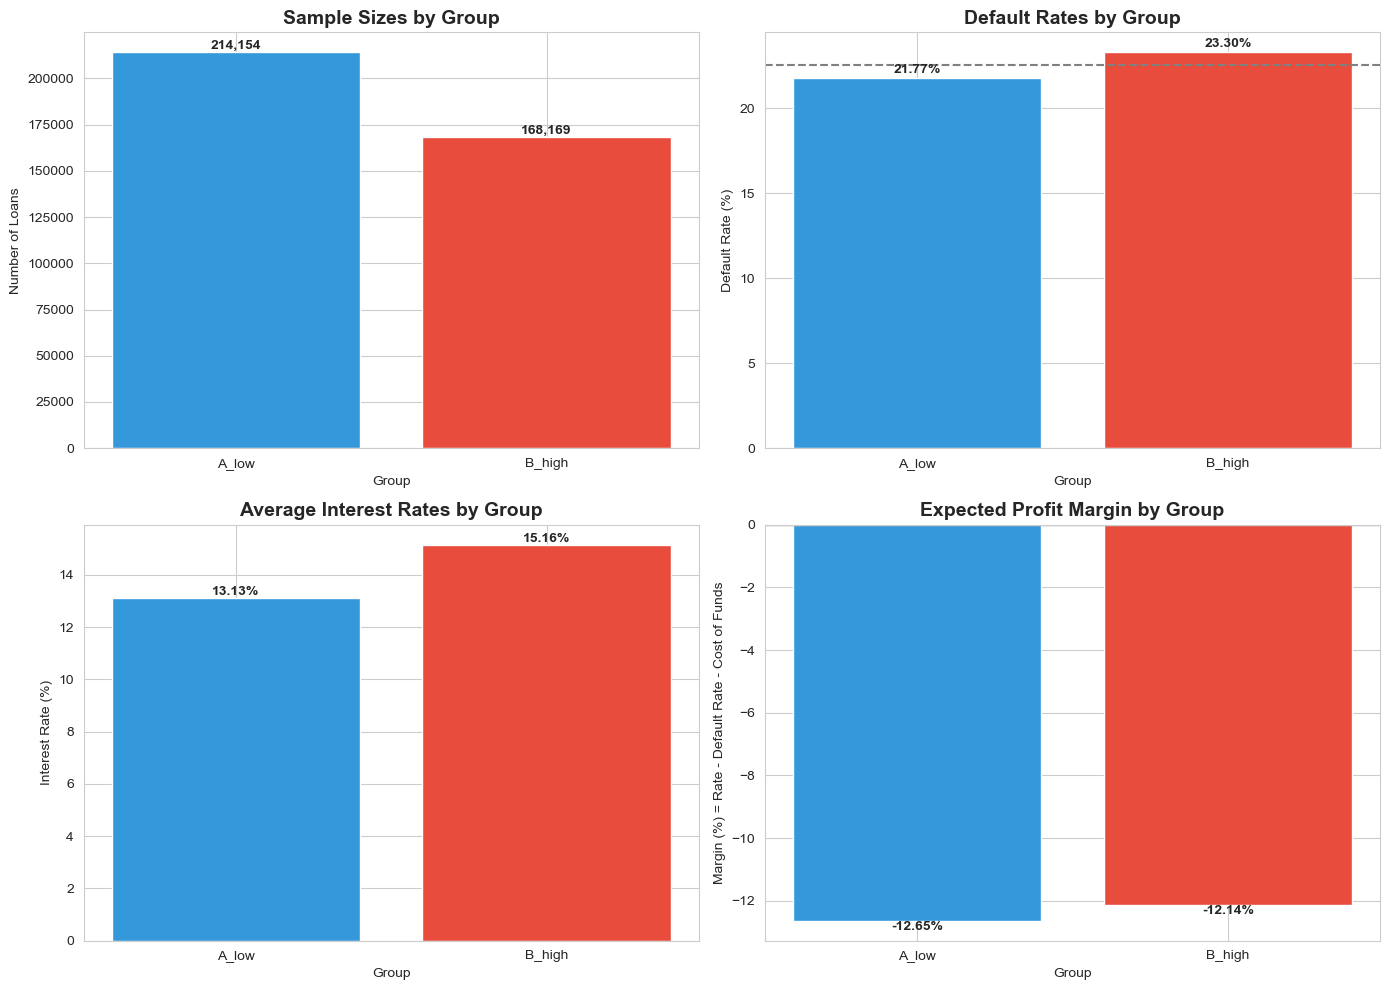

In [11]:
# 3. Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sample sizes
axes[0, 0].bar(summary['group'], summary['n_loans'], color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Sample Sizes by Group', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Loans')
axes[0, 0].set_xlabel('Group')
for i, v in enumerate(summary['n_loans']):
    axes[0, 0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Default rates
axes[0, 1].bar(summary['group'], summary['default_rate'] * 100, color=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Default Rates by Group', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].set_xlabel('Group')
axes[0, 1].axhline(y=summary['default_rate'].mean() * 100, color='gray', linestyle='--', label='Average')
for i, v in enumerate(summary['default_rate']):
    axes[0, 1].text(i, v * 100 + 0.3, f'{v*100:.2f}%', ha='center', fontweight='bold')

# Plot 3: Average interest rates
axes[1, 0].bar(summary['group'], summary['mean_rate'], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Average Interest Rates by Group', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Interest Rate (%)')
axes[1, 0].set_xlabel('Group')
for i, v in enumerate(summary['mean_rate']):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Plot 4: Margin analysis (assuming cost of funds = 4%)
cost_of_funds = 4.0
summary['expected_margin'] = summary['mean_rate'] - (summary['default_rate'] * 100) - cost_of_funds
axes[1, 1].bar(summary['group'], summary['expected_margin'], color=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Expected Profit Margin by Group', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Margin (%) = Rate - Default Rate - Cost of Funds')
axes[1, 1].set_xlabel('Group')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(summary['expected_margin']):
    axes[1, 1].text(i, v + 0.1 if v > 0 else v - 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings & Recommendations

Based on the A/B test results above:

1. **Statistical Significance**: The test shows whether the difference in default rates between high and low interest rate groups is statistically significant

2. **Risk-Return Trade-off**: Higher interest rates (Group B) generate more revenue but may have higher default rates

3. **Profitability**: The margin analysis shows which group is more profitable after accounting for defaults and cost of funds

4. **Business Decision**: Consider whether the additional revenue from higher rates justifies the increased default risk